Epoch 1/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 30s 949ms/step - loss: 0.3652 - val_loss: 0.1440
Epoch 2/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 906ms/step - loss: 0.0898 - val_loss: 0.0439
Epoch 3/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 901ms/step - loss: 0.0282 - val_loss: 0.0056
Epoch 4/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 26s 892ms/step - loss: 0.0033 - val_loss: 0.0026
Epoch 5/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - loss: 0.0027 - val_loss: 0.0027
Epoch 6/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 38s 1000ms/step - loss: 0.0024 - val_loss: 0.0024
Epoch 7/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - loss: 0.0025 - val_loss: 0.0020
Epoch 8/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 30s 1s/step - loss: 0.0025 - val_loss: 0.0020
Epoch 9/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 1s/step - loss: 0.0021 - val_loss: 0.0020
Epoch 10/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 30s 987ms/step - loss: 0.0020 - val_loss: 0.0027
Epoch 11/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 941ms/step - loss: 0.0022 - val_loss: 0.0020
Epoch 12/30
29/29 ━━━━━━━━━━━━━━━━━━━━ 27s 948ms/ste

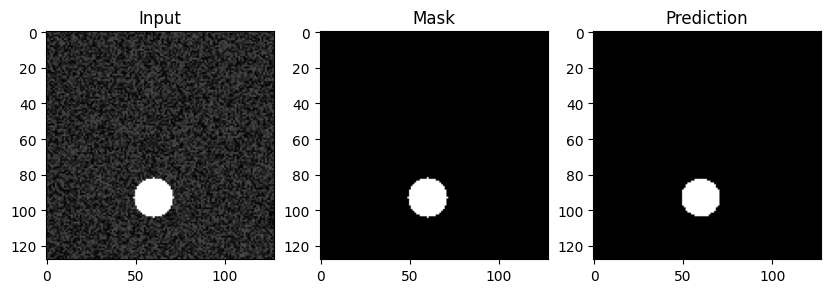

In [ ]:
import numpy as np
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
# 1. Dataset Generation
IMG_SIZE = 128

def create_sample():
    img = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)
    mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.float32)

    # random circle
    x = np.random.randint(30, 98)
    y = np.random.randint(30, 98)
    r = np.random.randint(10, 20)

    cv2.circle(mask, (x, y), r, 1, -1)

    noise = np.random.rand(IMG_SIZE, IMG_SIZE) * 0.3
    img = mask + noise

    img = np.clip(img, 0, 1)

    return img, mask

def create_dataset(n=500):
    X, Y = [], []
    for _ in range(n):
        img, mask = create_sample()
        X.append(img)
        Y.append(mask)

    X = np.array(X)[..., np.newaxis]
    Y = np.array(Y)[..., np.newaxis]
    return X, Y

X, Y = create_dataset(500)

# 2. U-Net Model
def unet():
    inputs = layers.Input((128,128,1))

    # Encoder
    c1 = layers.Conv2D(16, 3, activation='relu', padding='same')(inputs)
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(32, 3, activation='relu', padding='same')(p1)
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck
    b = layers.Conv2D(64, 3, activation='relu', padding='same')(p2)

    # Decoder
    u1 = layers.UpSampling2D()(b)
    c3 = layers.Conv2D(32, 3, activation='relu', padding='same')(u1)

    u2 = layers.UpSampling2D()(c3)
    c4 = layers.Conv2D(16, 3, activation='relu', padding='same')(u2)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c4)

    model = models.Model(inputs, outputs)
    return model
model = unet()
model.compile(optimizer='adam', loss='binary_crossentropy')
# 3. Training
history = model.fit(X, Y, epochs=30, batch_size=16, validation_split=0.1)
# 4. Prediction
test_img = X[0]
pred = model.predict(test_img[np.newaxis,...])[0]
pred = (pred > 0.5).astype(np.uint8)
# 5. Visualization
plt.figure(figsize=(10,3))

plt.subplot(1,3,1)
plt.title("Input")
plt.imshow(test_img.squeeze(), cmap='gray')

plt.subplot(1,3,2)
plt.title("Mask")
plt.imshow(Y[0].squeeze(), cmap='gray')

plt.subplot(1,3,3)
plt.title("Prediction")
plt.imshow(pred.squeeze(), cmap='gray')

plt.show()